In [1]:
import torch
from pytorch_pretrained_bert import BertTokenizer, BertModel, BertForMaskedLM

# OPTIONAL: if you want to have more information on what's happening, activate the logger as follows
import logging
#logging.basicConfig(level=logging.INFO)

import matplotlib.pyplot as plt
%matplotlib inline

# Load pre-trained model tokenizer (vocabulary)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

与Word2Vec之类的模型相比，BERT提供了一个优势，因为尽管Word2Vec下的每个单词都有一个固定的表示，而与单词出现的上下文无关，BERT生成的单词表示是由单词周围的单词动态通知的。例如，给定两句话：

“The man was accused of robbing a bank.” “The man went fishing by the bank of the river.”

Word2Vec将在两个句子中为单词“bank”生成相同的单词嵌入，而在BERT中为“bank”生成不同的单词嵌入。除了捕获一词多义之类的明显差异外，上下文相关的单词embeddings还捕获其他形式的信息，这些信息可以产生更精确的特征表示，从而提高模型性能。

从教育的角度看，仔细查看BERT的词嵌入的是一个深入学习BERT及其迁移学习模型的很好的方法，我们设置了一些实用知识和上下文，以便在后面的内容中更好地理解模型的内部细节。

安装和导入

使用Hugging Face的github仓库来安装pytorch接口。(这个库包含其他预训练语言模型的接口，比如OpenAI的GPT和GPT-2)我们之所以选择pytorch接口，是因为它在高级api(易于使用，但不能深入了解工作原理)和tensorflow代码(其中包含了很多细节，但通常会让我们忽略关于tensorflow的内容，此处的目的是BERT!)之间取得了很好的平衡。

!pip install pytorch-pretrained-bert
现在我们导入pytorch、预训练的BERT模型和BERT tokenizer。我们将在后面的教程中详细解释BERT模型，但这是谷歌发布的预训练模型，它在Wikipedia和Book Corpus上运行了很多很多小时，Book Corpus是一个包含+10,000本不同类型书籍的数据集。这个模型(稍加修改)在一系列任务中击败了NLP基准测试。谷歌发布了一些BERT模型的变体，但是我们在这里使用的是两个可用尺寸(“base”和“large”)中较小的一个。
输入格式

因为BERT是一个预训练的模型，它期望以特定的格式输入数据，所以我们需要：

句子的开始([CLS])和分隔/结尾([SEP])的特别标记
符合BERT中使用的固定词汇表的标记
BERT‘s tokenizer中的token id
掩码id，以指示序列中的哪些元素是令牌，哪些是填充元素
段id用于区分不同的句子
用于显示令牌在序列中的位置嵌入
幸运的是，这个接口为我们处理了这些输入规范中的一些，因此我们只需要手动创建其中的一些(我们将在另一个教程中重新讨论其他输入)。

特殊的标记

BERT可以接受一到两句话作为输入，并希望每句话的开头和结尾都有特殊的标记：

2个句子的输入:

[CLS] the man went to the store [SEP] he bought a gallon of milk [SEP]

1个句子的输入:

[CLS] the man went to the store [SEP]

In [2]:
# text1 = "Here is the sentence I want embeddings for."
# text2 = "After stealing money from the bank vault, the bank robber was seen fishing on the Mississippi river bank."
# marked_text = "[CLS] " + text1 + " [SEP] " + text2 + " [SEP] "

# print (marked_text)

In [63]:
text1 = '''
type Query {
  author(id: ID!): User!
  feed: [Post!]!
}
'''
text2 = '''
type User {
  id: ID!
  username: String!
  posts: [Post!]!
}
'''
text3 = '''

type Post {
  id: ID!
  title: String!
  author: User!
}
'''
marked_text = "[CLS] " + text1 + " [SEP] " + text2 + " [SEP] " + text3 + " [SEP] "
print(marked_text)


[CLS] 
type Query {
  author(id: ID!): User!
  feed: [Post!]!
}
 [SEP] 
type User {
  id: ID!
  username: String!
  posts: [Post!]!
}
 [SEP] 

type Post {
  id: ID!
  title: String!
  author: User!
}
 [SEP] 


In [64]:
tokenized_text = tokenizer.tokenize(marked_text)
print (tokenized_text)

['[CLS]', 'type', 'query', '{', 'author', '(', 'id', ':', 'id', '!', ')', ':', 'user', '!', 'feed', ':', '[', 'post', '!', ']', '!', '}', '[SEP]', 'type', 'user', '{', 'id', ':', 'id', '!', 'user', '##name', ':', 'string', '!', 'posts', ':', '[', 'post', '!', ']', '!', '}', '[SEP]', 'type', 'post', '{', 'id', ':', 'id', '!', 'title', ':', 'string', '!', 'author', ':', 'user', '!', '}', '[SEP]']


注意“embeddings”一词是如何表示的:

[‘em’, ‘##bed’, ‘##ding’, ‘##s’]

原来的单词被分成更小的子单词和字符。这些子单词前面的两个#号只是我们的tokenizer用来表示这个子单词或字符是一个更大单词的一部分，并在其前面加上另一个子单词的方法。因此，例如，' ##bed ' token与' bed 'token是分开的，当一个较大的单词中出现子单词bed时，使用第一种方法，当一个独立的token “thing you sleep on”出现时，使用第二种方法。

为什么会这样？这是因为BERT tokenizer 是用WordPiece模型创建的。这个模型使用贪心法创建了一个固定大小的词汇表，其中包含单个字符、子单词和最适合我们的语言数据的单词。由于我们的BERT tokenizer模型的词汇量限制大小为30,000，因此，用WordPiece模型生成一个包含所有英语字符的词汇表，再加上该模型所训练的英语语料库中发现的~30,000个最常见的单词和子单词。这个词汇表包含个东西：

整个单词
出现在单词前面或单独出现的子单词(“em”(如embeddings中的“em”)与“go get em”中的独立字符序列“em”分配相同的向量)
不在单词前面的子单词，在前面加上“##”来表示这种情况
单个字符
要在此模型下对单词进行记号化，tokenizer首先检查整个单词是否在词汇表中。如果没有，则尝试将单词分解为词汇表中包含的尽可能大的子单词，最后将单词分解为单个字符。注意，由于这个原因，我们总是可以将一个单词表示为至少是它的单个字符的集合。

因此，不是将词汇表中的单词分配给诸如“OOV”或“UNK”之类的全集令牌，而是将词汇表中没有的单词分解为子单词和字符令牌，然后我们可以为它们生成嵌入。

因此，我们没有将“embeddings”和词汇表之外的每个单词分配给一个重载的未知词汇表标记，而是将其拆分为子单词标记[' em '、' ##bed '、' ##ding '、' ##s ']，这些标记将保留原单词的一些上下文含义。我们甚至可以平均这些子单词的嵌入向量来为原始单词生成一个近似的向量。

下面是词汇表中包含的一些令牌示例。以两个#号开头的标记是子单词或单个字符。

In [65]:
list(tokenizer.vocab.keys())[2000:2020]

['to',
 'was',
 'he',
 'is',
 'as',
 'for',
 'on',
 'with',
 'that',
 'it',
 'his',
 'by',
 'at',
 'from',
 'her',
 '##s',
 'she',
 'you',
 'had',
 'an']

In [66]:
indexed_tokens = tokenizer.convert_tokens_to_ids(tokenized_text)

for tup in zip(tokenized_text, indexed_tokens):
 print (tup)

('[CLS]', 101)
('type', 2828)
('query', 23032)
('{', 1063)
('author', 3166)
('(', 1006)
('id', 8909)
(':', 1024)
('id', 8909)
('!', 999)
(')', 1007)
(':', 1024)
('user', 5310)
('!', 999)
('feed', 5438)
(':', 1024)
('[', 1031)
('post', 2695)
('!', 999)
(']', 1033)
('!', 999)
('}', 1065)
('[SEP]', 102)
('type', 2828)
('user', 5310)
('{', 1063)
('id', 8909)
(':', 1024)
('id', 8909)
('!', 999)
('user', 5310)
('##name', 18442)
(':', 1024)
('string', 5164)
('!', 999)
('posts', 8466)
(':', 1024)
('[', 1031)
('post', 2695)
('!', 999)
(']', 1033)
('!', 999)
('}', 1065)
('[SEP]', 102)
('type', 2828)
('post', 2695)
('{', 1063)
('id', 8909)
(':', 1024)
('id', 8909)
('!', 999)
('title', 2516)
(':', 1024)
('string', 5164)
('!', 999)
('author', 3166)
(':', 1024)
('user', 5310)
('!', 999)
('}', 1065)
('[SEP]', 102)


Segment ID

BERT接受了句子对的训练，并期望使用1和0来区分这两个句子。也就是说，对于“tokenized_text”中的每个标记，我们必须指定它属于哪个句子：句子0(一系列0)或句子1(一系列1)。对于我们的目的，单句输入只需要一系列的1，所以我们将为输入语句中的每个标记创建一个1向量。

如果你想处理两个句子，请将第一个句子中的每个单词加上“[SEP]”token赋值为0，第二个句子中的所有token赋值为1。

In [67]:
segments_ids = [1] * len(tokenized_text)
print (segments_ids)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


运行一下我们的例子

接下来，我们需要将数据转换为torch张量并调用BERT模型。BERT PyTorch接口要求数据使用torch张量而不是Python列表，所以我们在这里转换列表——这不会改变形状或数据。

eval()将我们的模型置于评估模式，而不是训练模式。在这种情况下，评估模式关闭了训练中使用的dropout正则化。

调用 from_pretrained 将从网上获取模型。当我们加载 bert-base-uncased时，我们会在日志中看到打印的模型定义。该模型是一个12层的深度神经网络！

In [68]:
# Convert inputs to PyTorch tensors
tokens_tensor = torch.tensor([indexed_tokens])
segments_tensors = torch.tensor([segments_ids])

# Load pre-trained model (weights)
model = BertModel.from_pretrained('/Users/zhenyankun.zyk/data/models/bert-base-uncased')

# Put the model in "evaluation" mode, meaning feed-forward operation.
model.eval()

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): BertLayerNorm()
    (dropout): Dropout(p=0.1)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0): BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): BertLayerNorm()
            (dropout): Dropout(p=0.1)
          )
        )
        (intermediate): BertIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=

接下来，让我们获取网络的隐藏状态。

torch.no_grad禁用梯度计算，节省内存，并加快计算速度(我们不需要梯度或反向传播，因为我们只是运行向前传播)。

In [69]:
# Predict hidden states features for each layerwith 
with torch.no_grad():
    encoded_layers, _ = model(tokens_tensor, segments_tensors)

In [70]:
print ("Number of layers:", len(encoded_layers))
layer_i = 0

print ("Number of batches:", len(encoded_layers[layer_i]))
batch_i = 0

print ("Number of tokens:", len(encoded_layers[layer_i][batch_i]))
token_i = 0

print ("Number of hidden units:", len(encoded_layers[layer_i][batch_i][token_i]))

Number of layers: 12
Number of batches: 1
Number of tokens: 61
Number of hidden units: 768


让我们快速查看一下给定层和token的值范围。

你将发现，所有层和token的范围都非常相似，大多数值位于[- 2,2]之间，少量值位于-10左右。

In [71]:
import numpy as np

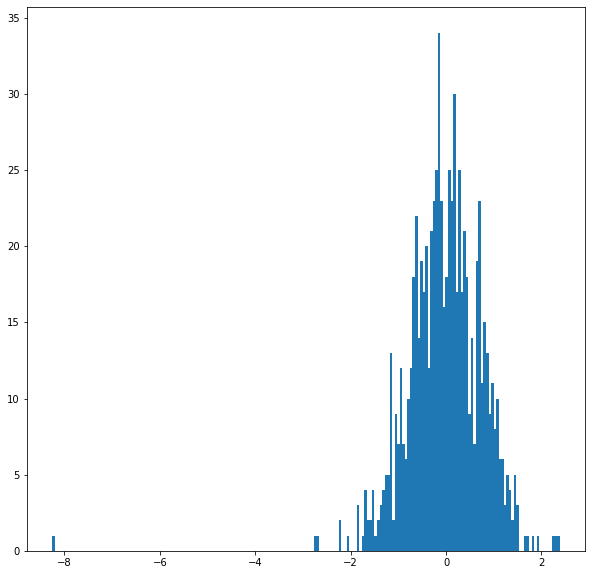

In [72]:
# For the 5th token in our sentence, select its feature values from layer 5.
token_i = 5
layer_i = 5
vec = encoded_layers[layer_i][batch_i][token_i]

# Plot the values as a histogram to show their distribution.
plt.figure(figsize=(10,10))
plt.hist(vec, bins=200)
plt.show()

In [73]:
# [# tokens, # layers, # features]
# Convert the hidden state embeddings into single token vectors

# Holds the list of 12 layer embeddings for each token
# Will have the shape: [# tokens, # layers, # features]
token_embeddings = []

# For each token in the sentence...
for token_i in range(len(tokenized_text)):
 # Holds 12 layers of hidden states for each token 
     hidden_layers = [] 
 
 # For each of the 12 layers...
     for layer_i in range(len(encoded_layers)):
         vec = encoded_layers[layer_i][batch_i][token_i]
         hidden_layers.append(vec)
         token_embeddings.append(hidden_layers)

# Sanity check the dimensions:
print ("Number of tokens in sequence:", len(token_embeddings))
print ("Number of layers per token:", len(token_embeddings[0]))

Number of tokens in sequence: 732
Number of layers per token: 12


词向量

为了给你一些例子，让我们用最后四层的连接和求和来创建单词向量：

In [74]:
concatenated_last_4_layers = [torch.cat((layer[-1], layer[-2], layer[-3], layer[-4]), 0) for layer in token_embeddings]

In [75]:
summed_last_4_layers = [torch.sum(torch.stack(layer)[-4:], 0) for layer in token_embeddings]

In [76]:
sentence_embedding = torch.mean(encoded_layers[11], 1)
print ("Our final sentence embedding vector of shape:",sentence_embedding[0].shape[0])

Our final sentence embedding vector of shape: 768


In [77]:
for i,x in enumerate(tokenized_text):
    print (i,x)

0 [CLS]
1 type
2 query
3 {
4 author
5 (
6 id
7 :
8 id
9 !
10 )
11 :
12 user
13 !
14 feed
15 :
16 [
17 post
18 !
19 ]
20 !
21 }
22 [SEP]
23 type
24 user
25 {
26 id
27 :
28 id
29 !
30 user
31 ##name
32 :
33 string
34 !
35 posts
36 :
37 [
38 post
39 !
40 ]
41 !
42 }
43 [SEP]
44 type
45 post
46 {
47 id
48 :
49 id
50 !
51 title
52 :
53 string
54 !
55 author
56 :
57 user
58 !
59 }
60 [SEP]


In [80]:
print ("First fifteen values of 'bank' as in 'bank robber':",summed_last_4_layers[1][:15])

First fifteen values of 'bank' as in 'bank robber': tensor([-4.2774, -2.2180, -1.1070,  0.4549,  0.2068,  1.8566, -0.9134,  1.4882,
         1.4218, -1.8353, -0.4044,  3.5716, -1.7936, -0.0488, -1.1213])


In [81]:
print ("First fifteen values of 'bank' as in 'bank vault':",summed_last_4_layers[23][:15])

First fifteen values of 'bank' as in 'bank vault': tensor([ 1.4993, -0.6249,  2.2909, -3.2843, -1.3983,  0.4109,  1.1442,  0.1843,
         4.1599, -1.9601,  0.6219,  0.2068, -0.8690,  1.8094, -0.7122])


In [82]:
print ("First fifteen values of 'bank' as in 'river bank':",summed_last_4_layers[44][:15])

First fifteen values of 'bank' as in 'river bank': tensor([-5.7501,  0.8281, -2.1312, -4.4802,  3.7468,  3.7661, -1.9048,  3.5770,
        -1.8713, -0.2639,  2.0246,  1.4409, -2.1196, -0.4251,  0.0298])


我们可以看到，这些都是不同的向量，它们应该是不同的，虽然单词“bank”是相同的，但在我们的每个句子中，它都有不同的含义，有时意义非常不同。

在这个句子中，我们有三种不同的“bank”用法，其中两种几乎是相同的。让我们检查余弦相似度，看看是不是这样：

In [83]:
from sklearn.metrics.pairwise import cosine_similarity
# Compare "bank" as in "bank robber" to "bank" as in "river bank"
different_bank = cosine_similarity(summed_last_4_layers[1].reshape(1,-1), summed_last_4_layers[23].reshape(1,-1))[0][0]

# Compare "bank" as in "bank robber" to "bank" as in "bank vault" 
same_bank = cosine_similarity(summed_last_4_layers[1].reshape(1,-1), summed_last_4_layers[44].reshape(1,-1))[0][0]
print ("Similarity of 'bank' as in 'bank robber' to 'bank' as in 'bank vault':", same_bank)

Similarity of 'bank' as in 'bank robber' to 'bank' as in 'bank vault': 0.39078197


In [84]:
print ("Similarity of 'bank' as in 'bank robber' to 'bank' as in 'river bank':", different_bank)

Similarity of 'bank' as in 'bank robber' to 'bank' as in 'river bank': 0.4149114


其他：特殊的tokens，OOV单词，相似度度量
特殊tokens

需要注意的是，虽然“[CLS]”用作分类任务的“聚合表示”，但对于高质量的句子嵌入向量来说，这不是最佳选择。根据BERT作者Jacob Devlin:

我不确定这些向量是什么，因为BERT不能生成有意义的句子向量。这似乎是在对单词tokens进行平均池化，以获得一个句子向量，但我们从未建议这将生成有意义的句子表示。”

(但是，如果对模型进行微调，[CLS] token确实变得有意义，其中该token的最后一个隐藏层用作序列分类的“句子向量”。)

词汇表之外的单词

对于由多个句子和字符级嵌入组成的词汇表之外的单词，还有一个进一步的问题，即如何最好地恢复这种嵌入。平均嵌入是最直接的解决方案(在类似的嵌入模型中依赖于子单词词汇表(如fasttext))，但是子单词嵌入的总和和简单地使用最后一个token嵌入(记住向量是上下文敏感的)是可接受的替代策略。

相似度度量

值得注意的是，单词级相似度比较不适用于BERT embeddings，因为这些嵌入是上下文相关的，这意味着单词vector会根据它出现在的句子而变化。这就允许了像一词多义这样的奇妙的东西，例如，你的表示编码了river “bank”，而不是金融机构“bank”，但却使得直接的词与词之间的相似性比较变得不那么有价值。但是，对于句子嵌入相似性比较仍然是有效的，这样就可以对一个句子查询其他句子的数据集，从而找到最相似的句子。根据使用的相似度度量，得到的相似度值将比相似度输出的相对排序提供的信息更少，因为许多相似度度量对向量空间(例如，等权重维度)做了假设，而这些假设不适用于768维向量空间。

英文原文：https://mccormickml.com/2019/05/14/BERT-word-embeddings-tutorial/

In [85]:
print('First 5 vector values for each instance of "bank".')
print('')
print("post start  ", str(summed_last_4_layers[17][:5]))
print("posts  ", str(summed_last_4_layers[35][:5]))
print("post items1  ", str(summed_last_4_layers[38][:5]))
print("post items2   ", str(summed_last_4_layers[45][:5]))

First 5 vector values for each instance of "bank".

post start   tensor([ 1.4993, -0.6249,  2.2909, -3.2843, -1.3983])
posts   tensor([ 1.0543, -0.3329,  2.6780, -1.9495,  4.2693])
post items1   tensor([-5.7501,  0.8281, -2.1312, -4.4802,  3.7468])
post items2    tensor([-5.7501,  0.8281, -2.1312, -4.4802,  3.7468])


In [89]:
from scipy.spatial.distance import cosine

# Calculate the cosine similarity between the word bank 
# in "bank robber" vs "river bank" (different meanings).
diff_bank = 1 - cosine(summed_last_4_layers[35][:25], summed_last_4_layers[17][:25])
diff_bank1 = 1 - cosine(summed_last_4_layers[35][:25], summed_last_4_layers[38][:25])
diff_items = 1 - cosine(summed_last_4_layers[45][:25], summed_last_4_layers[17][:25])

# Calculate the cosine similarity between the word bank
# in "bank robber" vs "bank vault" (same meaning).
same_bank = 1 - cosine(summed_last_4_layers[38][:25], summed_last_4_layers[45][:25])

print('Vector similarity for  *similar*  meanings:  %.2f' % same_bank)
print('Vector similarity for *different* meanings:  %.2f' % diff_bank)
print('Vector similarity for *different* meanings:  %.2f' % diff_bank1)
print('Vector similarity for *different* meanings:  %.2f' % diff_items)

Vector similarity for  *similar*  meanings:  1.00
Vector similarity for *different* meanings:  0.43
Vector similarity for *different* meanings:  0.41
Vector similarity for *different* meanings:  0.23


In [90]:
tmp = '''
{
  "operation": {
    "kind": "OperationDefinition",
    "operation": "query",
    "name": {
      "kind": "Name",
      "value": "AuthorWithPosts"
    },
    "selectionSet": {
      "kind": "SelectionSet",
      "selections": [
        {
          "kind": "Field",
          "name": {
            "kind": "Name",
            "value": "author"
          },
          "arguments": [
            {
              "kind": "Argument",
              "name": {
                "kind": "Name",
                "value": "id"
              },
              "value": {
                "kind": "StringValue",
                "value": "user-1"
              }
            }
          ],
          "selectionSet": {
            "kind": "SelectionSet",
            "selections": [
              {
                "kind": "Field",
                "name": {
                  "kind": "Name",
                  "value": "username"
                }
              },
              {
                "kind": "Field",
                "name": {
                  "kind": "Name",
                  "value": "posts"
                },
                "selectionSet": {
                  "kind": "SelectionSet",
                  "selections": [
                    {
                      "kind": "Field",
                      "name": {
                        "kind": "Name",
                        "value": "id"
                      }
                    },
                    {
                      "kind": "Field",
                      "name": {
                        "kind": "Name",
                        "value": "title"
                      }
                    }
                  ]
                }
              }
            ]
          }
        }
      ]
    }
  }
}
'''
print(tmp)


{
  "operation": {
    "kind": "OperationDefinition",
    "operation": "query",
    "name": {
      "kind": "Name",
      "value": "AuthorWithPosts"
    },
    "selectionSet": {
      "kind": "SelectionSet",
      "selections": [
        {
          "kind": "Field",
          "name": {
            "kind": "Name",
            "value": "author"
          },
          "arguments": [
            {
              "kind": "Argument",
              "name": {
                "kind": "Name",
                "value": "id"
              },
              "value": {
                "kind": "StringValue",
                "value": "user-1"
              }
            }
          ],
          "selectionSet": {
            "kind": "SelectionSet",
            "selections": [
              {
                "kind": "Field",
                "name": {
                  "kind": "Name",
                  "value": "username"
                }
              },
              {
                "kind": "Field",
 

In [91]:
from __future__ import division
import nltk
import matplotlib
from nltk.book import *
from nltk.util import bigrams

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


词汇分布表


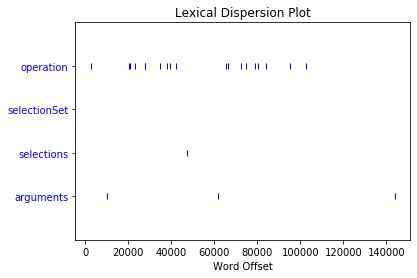

In [92]:
# 词汇分布表
print('词汇分布表')
text4.dispersion_plot(['operation', 'selectionSet', 'selections', 'arguments'])

In [93]:
tokens = nltk.word_tokenize(tmp)
print(tokens)

['{', '``', 'operation', "''", ':', '{', '``', 'kind', "''", ':', '``', 'OperationDefinition', "''", ',', '``', 'operation', "''", ':', '``', 'query', "''", ',', '``', 'name', "''", ':', '{', '``', 'kind', "''", ':', '``', 'Name', "''", ',', '``', 'value', "''", ':', '``', 'AuthorWithPosts', "''", '}', ',', '``', 'selectionSet', "''", ':', '{', '``', 'kind', "''", ':', '``', 'SelectionSet', "''", ',', '``', 'selections', "''", ':', '[', '{', '``', 'kind', "''", ':', '``', 'Field', "''", ',', '``', 'name', "''", ':', '{', '``', 'kind', "''", ':', '``', 'Name', "''", ',', '``', 'value', "''", ':', '``', 'author', "''", '}', ',', '``', 'arguments', "''", ':', '[', '{', '``', 'kind', "''", ':', '``', 'Argument', "''", ',', '``', 'name', "''", ':', '{', '``', 'kind', "''", ':', '``', 'Name', "''", ',', '``', 'value', "''", ':', '``', 'id', "''", '}', ',', '``', 'value', "''", ':', '{', '``', 'kind', "''", ':', '``', 'StringValue', "''", ',', '``', 'value', "''", ':', '``', 'user-1', "''", '

In [99]:
# 借⽤用NLTK的FreqDist统计⼀一下⽂文字出现的频率
fdist = FreqDist(tokens)

# 它就类似于⼀一个Dict
# 带上某个单词, 可以看到它在整个⽂文章中出现的次数
print('operation',fdist['operation'])
print('selectionSet',fdist['selectionSet'])
print('selections',fdist['selections'])
print('arguments',fdist['arguments'])

operation 2
selectionSet 3
selections 3
arguments 1


In [101]:
# 好, 此刻, 我们可以把最常⽤用的50个单词拿出来
standard_freq_vector = fdist.most_common(20)
size = len(standard_freq_vector)
print(standard_freq_vector)
print("size",size)

[('``', 70), ("''", 70), (':', 43), (',', 26), ('{', 19), ('}', 19), ('kind', 18), ('value', 9), ('name', 7), ('Name', 7), ('Field', 5), ('[', 4), (']', 4), ('selectionSet', 3), ('SelectionSet', 3), ('selections', 3), ('operation', 2), ('id', 2), ('OperationDefinition', 1), ('query', 1)]
size 20


In [102]:
def position_lookup(v):
    res = {}
    counter = 0
    for word in v:
        res[word[0]] = counter
        counter += 1
    return res

# 把标准的单词位置记录下来
standard_position_dict = position_lookup(standard_freq_vector)
print(standard_position_dict)

{'``': 0, "''": 1, ':': 2, ',': 3, '{': 4, '}': 5, 'kind': 6, 'value': 7, 'name': 8, 'Name': 9, 'Field': 10, '[': 11, ']': 12, 'selectionSet': 13, 'SelectionSet': 14, 'selections': 15, 'operation': 16, 'id': 17, 'OperationDefinition': 18, 'query': 19}


In [103]:
# 这时, 如果我们有个新句句⼦子:
sentence = '''
type Query {
  author(id: ID!): User!
  feed: [Post!]!
}
'''
# 先新建⼀一个跟我们的标准vector同样⼤大⼩小的向量量
freq_vector = [0] * size
# 简单的Preprocessing
tokens = nltk.word_tokenize(sentence)
# 对于这个新句句⼦子⾥里里的每⼀一个单词
for word in tokens:
    try:
        # 如果在我们的词库⾥里里出现过
        # 那么就在"标准位置"上+1
        freq_vector[standard_position_dict[word]] += 1
    except KeyError:
        # 如果是个新词
        # 就pass掉
        continue
    print(freq_vector)
        # [1, 1, 0, 0, 0, 0, 0]
        # 第⼀一个位置代表 is, 出现了了⼀一次
        # 第⼆二个位置代表 this, 出现了了⼀一次

[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 3, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 3, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0]
